# 2025-26 Filter Coverage — Yield, Watchlist Precision, Re-filter Verdicts

**Objective:** Verify the filter output before any batch spend (#30 tail — the
post-filter, pre-batch checkpoint, and the last free moment to change the population).
Deliverable: this notebook + small derived parquets under
`data/2025-26/reference/coverage/`, ending in a per-alias verdict table that becomes
the `players.yaml` fix list for the re-filter.

**This notebook answers:**

- §1 — What did the filter yield, and is the output internally sound?
- §2 — Who cleared the 5,000-comment threshold: did the storyline adds and the v1
  "could qualify" five pay off, and which config entries are dead weight?
- §3 — Are the 15 watchlist aliases matching the right player (precision), and how
  much contamination does each carry?
- §4 — What config fixes follow, and what population delta should the re-filter
  expect?

## Load Data

The mentions file (`data/2025-26/filtered/r_nba_player_mentions.jsonl`, ~1.1 GB) is
scanned once per metric family via DuckDB `read_ndjson` with explicit column specs;
results persist as small parquets so later cells and sessions reuse instead of
rescanning.

Guardrails:

- **`body` is projected in exactly one place** — the §3 watchlist pass — because alias
  precision *is* a body-context question. It lives in a session-local DuckDB temp
  table, restricted to rows attributed to the 15 watchlist players, and is never
  persisted: the artifacts keep only per-alias stats and capped ±60-char context
  snippets (the verification evidence).
- Every scan cell is guarded on artifact existence, with a staleness warning if the
  artifact predates the mentions file — which is exactly what will happen after the
  re-filter, flagging every cell for re-run.
- **This file predates the `eason` short-guard** (staged in the working tree, not yet
  filtered), so §1's yield is knowingly inflated by "season"/"reason" bleed; §3
  quantifies it.

In [1]:
import os
import re
import sys
from datetime import datetime, timezone
from pathlib import Path

# Bootstrap: run from anywhere (see 01/02 — walk up to the repo root, chdir).
_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import duckdb
import matplotlib.pyplot as plt
import polars as pl

from pipeline.aggregation import extract_team_from_flair
from utils.paths import get_data_dir
from utils.player_config import load_player_config
from utils.season_config import get_active_season
from utils.team_config import build_alias_to_team_map

SEASON = "2025-26"  # pinned: this notebook is season-scoped (notebooks/2025-26/)
assert get_active_season() == SEASON, "active season flipped — review before re-running"

MENTIONS_RAW = get_data_dir(season=SEASON) / "filtered" / "r_nba_player_mentions.jsonl"
CORPUS_DIR = get_data_dir(season=SEASON) / "reference" / "corpus"
COVERAGE_DIR = get_data_dir(season=SEASON) / "reference" / "coverage"
COVERAGE_DIR.mkdir(parents=True, exist_ok=True)
assert MENTIONS_RAW.exists(), f"missing mentions file: {MENTIONS_RAW}"

# Denominators come from 02's persisted artifacts — no raw rescans here.
CORPUS_TOTAL = pl.read_parquet(CORPUS_DIR / "comments_census.parquet")["n_comments"][0]
V1_RAW_TOTAL = pl.read_parquet(CORPUS_DIR / "v1_comments_census.parquet")["n_comments"][0]
V1_PLAYER_OVERALL = get_data_dir(season="2024-25") / "dashboard" / "player_overall.parquet"
V1_ATTRIBUTED = int(
    duckdb.sql(f"SELECT sum(comment_count) AS n FROM '{V1_PLAYER_OVERALL}'").pl()["n"][0]
)
V1_MATCH_RATE = V1_ATTRIBUTED / V1_RAW_TOTAL

# The production config: players + the word-boundary guard set. NOTE: the
# working tree stages `eason` into short_aliases, so `guarded_in_config` below
# reflects the PROPOSED state; the §3 empirical split shows what the FILE did.
players, short_aliases = load_player_config()
assert "eason" in short_aliases, "expected the staged eason guard in short_aliases"

# The 15 watchlist pairs — mirrors the inline `# watchlist` markers in
# players.yaml plus the post-filter eason catch.
WATCHLIST = [
    ("Jarrett Allen", "one of us"),
    ("Scottie Barnes", "barnes"),
    ("Scottie Barnes", "scottie"),
    ("RJ Barrett", "rj"),
    ("Malik Beasley", "beasley"),
    ("Jaylen Brown", "brown"),
    ("Jaylen Brown", "jb"),
    ("Jalen Brunson", "the captain"),
    ("Gradey Dick", "dick"),
    ("Tari Eason", "eason"),
    ("De'Andre Hunter", "hunter"),
    ("Bennedict Mathurin", "benny"),
    ("Andrew Nembhard", "nembhard"),
    ("Terry Rozier", "terry"),
    ("Jabari Smith Jr.", "jabari"),
]
# WATCHLIST pins the config-as-filtered. Once this notebook's verdicts land in
# players.yaml, dropped aliases disappear from the live config — report the
# drift, don't crash on it.
for _p, _a in WATCHLIST:
    assert _p in players, f"watchlist player not in config: {_p}"
    if _a not in [x.lower() for x in players[_p]]:
        print(f"note: {_a!r} no longer an alias of {_p} (dropped/moved by this notebook's verdicts)")
WATCHLIST_PLAYERS = sorted({p for p, _ in WATCHLIST})


def warn_if_stale(pq: Path, raw: Path) -> None:
    """Companion to the existence-only reuse guards: flag a persisted
    artifact older than the file it derives from."""
    if pq.exists() and pq.stat().st_mtime < raw.stat().st_mtime:
        print(f"WARNING: {pq.name} predates {raw.name} — delete it to force a rescan")


def sql_quote(s: str) -> str:
    """Escape a string for embedding in a single-quoted SQL literal
    (De'Andre, Shai's, ...)."""
    return s.replace("'", "''")


TEAM_MAP = build_alias_to_team_map()

duckdb.sql("SET temp_directory = '/tmp/duckdb_coverage_spill'")

print(f"Mentions file: {MENTIONS_RAW}  ({MENTIONS_RAW.stat().st_size / 1e9:.1f} GB)")
print(f"Corpus total (02 census): {CORPUS_TOTAL:,}")
print(f"v1 match rate: {V1_ATTRIBUTED:,} / {V1_RAW_TOTAL:,} = {V1_MATCH_RATE:.1%}")
print(f"Config: {len(players)} players, {len(short_aliases)} short (word-boundary) aliases")
print(f"Watchlist: {len(WATCHLIST)} aliases across {len(WATCHLIST_PLAYERS)} players")

note: 'one of us' no longer an alias of Jarrett Allen (dropped/moved by this notebook's verdicts)
note: 'barnes' no longer an alias of Scottie Barnes (dropped/moved by this notebook's verdicts)
note: 'brown' no longer an alias of Jaylen Brown (dropped/moved by this notebook's verdicts)
note: 'the captain' no longer an alias of Jalen Brunson (dropped/moved by this notebook's verdicts)
note: 'dick' no longer an alias of Gradey Dick (dropped/moved by this notebook's verdicts)
note: 'benny' no longer an alias of Bennedict Mathurin (dropped/moved by this notebook's verdicts)
note: 'terry' no longer an alias of Terry Rozier (dropped/moved by this notebook's verdicts)
Mentions file: data/2025-26/filtered/r_nba_player_mentions.jsonl  (1.0 GB)
Corpus total (02 census): 7,283,478
v1 match rate: 1,567,722 / 7,041,235 = 22.3%
Config: 223 players, 109 short (word-boundary) aliases
Watchlist: 15 aliases across 13 players


## 1. Filter yield & integrity

One pass at row grain: total yield vs the corpus and the v1-rate expectation,
duplicate-id check (inherited hard from 02's philosophy — dupes corrupt), empty-mention
rows (should be zero: the filter's contract is "kept ⇒ attributed"), and the
mentions-per-comment distribution.

In [2]:
# §1 scan — the ONE row-grain pass over the mentions file. body not projected.
YIELD_PQ = COVERAGE_DIR / "mentions_census.parquet"
NPLAYERS_PQ = COVERAGE_DIR / "mentions_per_comment.parquet"

if not (YIELD_PQ.exists() and NPLAYERS_PQ.exists()):
    _scan = duckdb.sql(f"""
        SELECT
            grouping(n_players) = 1 AS is_total,
            n_players,
            count(*)                AS n_rows,
            count(DISTINCT id)      AS n_distinct_ids,
            min(created_utc)        AS min_utc,
            max(created_utc)        AS max_utc
        FROM (
            SELECT id, created_utc, len(mentioned_players) AS n_players
            FROM read_ndjson('{MENTIONS_RAW}',
                format = 'newline_delimited',
                columns = {{id: 'VARCHAR', created_utc: 'BIGINT',
                            mentioned_players: 'VARCHAR[]'}})
        )
        GROUP BY GROUPING SETS ((n_players), ())
    """).pl()
    _scan.filter(pl.col("is_total")).drop("is_total", "n_players").write_parquet(YIELD_PQ)
    _scan.filter(~pl.col("is_total")).drop("is_total").sort("n_players").write_parquet(NPLAYERS_PQ)
    print("scanned mentions file; census + per-comment parquets persisted")
else:
    print("reusing persisted parquets (no rescan)")
for _pq in (YIELD_PQ, NPLAYERS_PQ):
    warn_if_stale(_pq, MENTIONS_RAW)

myield = pl.read_parquet(YIELD_PQ).row(0, named=True)
nplayers = pl.read_parquet(NPLAYERS_PQ)

# Duplicate ids stay a HARD assert (02's philosophy: corruption, not incompleteness).
assert myield["n_distinct_ids"] == myield["n_rows"], "duplicate ids in filter output"
# The filter's contract: every kept row has at least one attributed player.
_empty = nplayers.filter(pl.col("n_players") == 0)
assert _empty.height == 0, f"rows with empty mentioned_players: {_empty['n_rows'].sum()}"

_min_day = datetime.fromtimestamp(myield["min_utc"], tz=timezone.utc).date()
_max_day = datetime.fromtimestamp(myield["max_utc"], tz=timezone.utc).date()
match_rate = myield["n_rows"] / CORPUS_TOTAL
expected_floor = V1_MATCH_RATE * CORPUS_TOTAL

print(f"yield:      {myield['n_rows']:,} rows ({match_rate:.1%} of the {CORPUS_TOTAL:,} corpus)")
print(f"expected:   ~{expected_floor:,.0f} at v1's {V1_MATCH_RATE:.1%} rate (floor; config broadened)")
print(f"window:     {_min_day} → {_max_day}")
print("caveat: yield includes eason's season/reason bleed — §3 quantifies, §4 nets it out")
print("\nmentions per comment:")
display(nplayers.select("n_players", "n_rows").with_columns(
    (pl.col("n_rows") / myield["n_rows"]).round(4).alias("share")))

scanned mentions file; census + per-comment parquets persisted
yield:      2,154,982 rows (29.6% of the 7,283,478 corpus)
expected:   ~1,621,657 at v1's 22.3% rate (floor; config broadened)
window:     2025-10-01 → 2026-06-30
caveat: yield includes eason's season/reason bleed — §3 quantifies, §4 nets it out

mentions per comment:


n_players,n_rows,share
i64,i64,f64
1,1537415,0.7134
2,422731,0.1962
3,114185,0.053
4,42810,0.0199
5,18194,0.0084
…,…,…
60,1,0.0
61,1,0.0
71,1,0.0


## 2. Per-player volumes — who clears the bar

Explode `mentioned_players` once. Checks, in order of stakes: the storyline adds
(Rozier, Ivey, Beasley — config v2.0/v3.0 exist *for* these), the v1 "could qualify in
v2" five (analysis doc §6), and config dead weight (players the discourse ignores).
Threshold = 5,000 (the published qualified bar).

scanned mentions file; player counts persisted
223/223 config players attributed at least once
clearing the 5,000 bar: 105


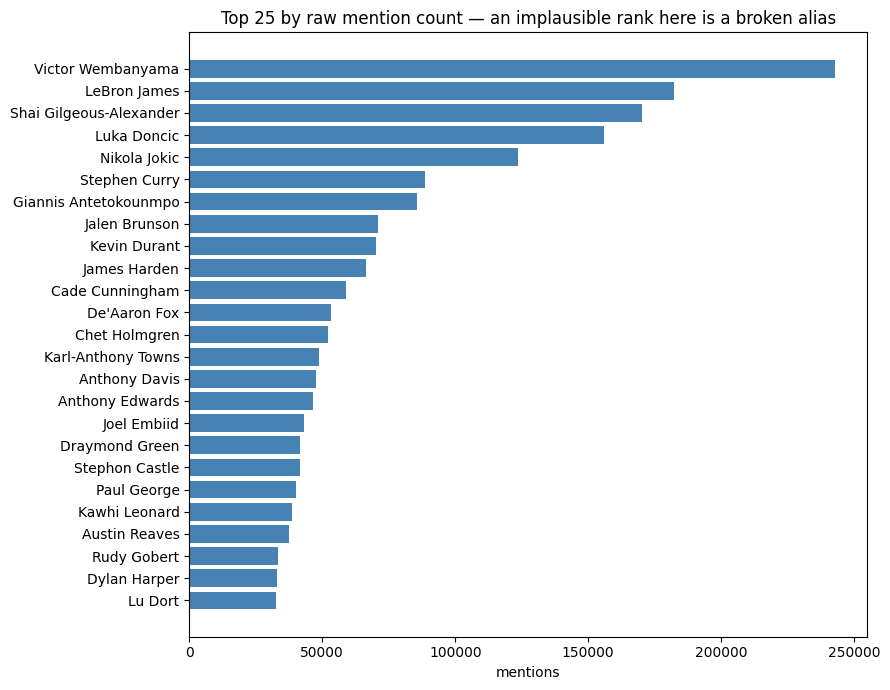


storyline adds (config v2.0/v3.0):
  Terry Rozier              2,901  58% of bar
  Jaden Ivey                3,641  73% of bar
  Malik Beasley             1,534  31% of bar

v1 'could qualify in v2' (analysis doc §6):
  Bradley Beal              4,615  92% of bar
  Lu Dort                  32,717  QUALIFIES
  Michael Porter Jr         9,220  QUALIFIES
  Jalen Green               2,558  51% of bar
  Dillon Brooks            15,538  QUALIFIES

zero mentions: 0 players 


player,mentions
str,i64
"""Collin Murray-Boyles""",150
"""GG Jackson""",181
"""Moses Moody""",186
"""Gary Trent Jr.""",199
"""Nikola Topić""",244
…,…
"""Nickeil Alexander-Walker""",394
"""Wendell Carter Jr.""",401
"""Isaac Okoro""",430


In [3]:
# §2 scan — the ONE exploded-grain pass. body not projected.
COUNTS_PQ = COVERAGE_DIR / "player_mention_counts.parquet"

if not COUNTS_PQ.exists():
    duckdb.sql(f"""
        COPY (
            SELECT player, count(*) AS mentions
            FROM (
                SELECT unnest(mentioned_players) AS player
                FROM read_ndjson('{MENTIONS_RAW}',
                    format = 'newline_delimited',
                    columns = {{mentioned_players: 'VARCHAR[]'}})
            )
            GROUP BY player
        ) TO '{COUNTS_PQ}' (FORMAT parquet)
    """)
    print("scanned mentions file; player counts persisted")
else:
    print("reusing persisted player counts (no rescan)")
warn_if_stale(COUNTS_PQ, MENTIONS_RAW)

counts = pl.read_parquet(COUNTS_PQ).sort("mentions", descending=True)
# Attribution integrity: every attributed name must be a config player.
_unknown = counts.filter(~pl.col("player").is_in(list(players)))
assert _unknown.height == 0, f"attributed names not in config: {_unknown['player'].to_list()}"

QUALIFIED_BAR = 5_000
print(f"{counts.height}/{len(players)} config players attributed at least once")
print(f"clearing the {QUALIFIED_BAR:,} bar: {counts.filter(pl.col('mentions') >= QUALIFIED_BAR).height}")

fig, ax = plt.subplots(figsize=(9, 7))
_top = counts.head(25).reverse()
ax.barh(_top["player"], _top["mentions"], color="steelblue")
ax.set_title("Top 25 by raw mention count — an implausible rank here is a broken alias")
ax.set_xlabel("mentions")
plt.tight_layout()
plt.show()

STORYLINE_ADDS = ["Terry Rozier", "Jaden Ivey", "Malik Beasley"]
V1_COULD_QUALIFY = ["Bradley Beal", "Lu Dort", "Michael Porter Jr", "Jalen Green", "Dillon Brooks"]


def volume_check(names: list[str], label: str) -> None:
    """Print mention volume vs the qualified bar for a named cohort."""
    print(f"\n{label}:")
    for _n in names:
        _row = counts.filter(pl.col("player") == _n)
        _m = _row["mentions"][0] if _row.height else 0
        _mark = "QUALIFIES" if _m >= QUALIFIED_BAR else f"{_m / QUALIFIED_BAR:.0%} of bar"
        print(f"  {_n:<22} {_m:>8,}  {_mark}")


volume_check(STORYLINE_ADDS, "storyline adds (config v2.0/v3.0)")
volume_check(V1_COULD_QUALIFY, "v1 'could qualify in v2' (analysis doc §6)")

# Dead weight: tracked but ignored by the discourse (candidates to prune, not
# a config error — a thin market with one star is accurate, per 01's method).
_zero = sorted(set(players) - set(counts["player"].to_list()))
print(f"\nzero mentions: {len(_zero)} players {_zero if _zero else ''}")
display(counts.filter(pl.col("mentions") < 500).sort("mentions"))

## 3. Watchlist alias precision

Method: for each watchlist pair (player, alias), isolate **alias-only rows** — rows
attributed to the player where *no other* of their aliases appears in the body — since
those exist *because of* the risky alias. Split them **word-boundary vs substring-only**
(substring-only = would not have matched under a `short_aliases` guard), and pull capped
±60-char context snippets for the judgment call the numbers can't make: whether the
word, even on a boundary, refers to the right person.

Two different questions by guard status: for config-guarded aliases the substring-only
count should be **zero** (nonzero = the file predates the guard — expected here for
`eason`); for unguarded aliases it measures the bleed a guard would remove. Bodies stay
in a session-local temp table; only stats and snippets persist.

In [4]:
# §3 build — the ONE body-projecting pass, restricted to watchlist players.
STATS_PQ = COVERAGE_DIR / "watchlist_alias_stats.parquet"
SAMPLES_PQ = COVERAGE_DIR / "watchlist_samples.parquet"
SPLIT_PQ = COVERAGE_DIR / "referent_split.parquet"
FLAIR_SPLIT_PQ = COVERAGE_DIR / "referent_flair_split.parquet"
_ALL_WL_PQS = (STATS_PQ, SAMPLES_PQ, SPLIT_PQ, FLAIR_SPLIT_PQ)
_wl_list = "[" + ", ".join(f"'{sql_quote(p)}'" for p in WATCHLIST_PLAYERS) + "]"

if not all(p.exists() for p in _ALL_WL_PQS):
    duckdb.sql(f"""
        CREATE OR REPLACE TEMP TABLE wl AS
        SELECT id, score, created_utc, author_flair_text,
               mentioned_players, lower(body) AS body_lc
        FROM read_ndjson('{MENTIONS_RAW}',
            format = 'newline_delimited',
            columns = {{id: 'VARCHAR', score: 'BIGINT', created_utc: 'BIGINT',
                        author_flair_text: 'VARCHAR', body: 'VARCHAR',
                        mentioned_players: 'VARCHAR[]'}})
        WHERE list_has_any(mentioned_players, {_wl_list})
    """)
    _n_wl = duckdb.sql("SELECT count(*) AS n FROM wl").pl()["n"][0]
    print(f"temp table: {_n_wl:,} rows attributed to watchlist players (bodies stay in-session)")
else:
    print("reusing all persisted §3 artifacts (no rescan, no temp table)")
for _pq in _ALL_WL_PQS:
    warn_if_stale(_pq, MENTIONS_RAW)


def alias_only_condition(player: str, alias: str) -> str:
    """SQL predicate: row attributed to `player` where NO other alias of
    theirs fires under production semantics (word boundary for short-guarded
    others, substring for the rest) — the rows that exist because of `alias`."""
    _others = [x.lower() for x in players[player] if x.lower() != alias] + [player.lower()]
    _no_other = " AND ".join(
        (
            f"NOT regexp_matches(body_lc, '\\b{re.escape(o)}\\b')"
            if o in short_aliases
            else f"NOT contains(body_lc, '{sql_quote(o)}')"
        )
        for o in _others
    )
    return f"list_contains(mentioned_players, '{sql_quote(player)}') AND {_no_other}"

temp table: 135,496 rows attributed to watchlist players (bodies stay in-session)


In [5]:
# §3 stats + samples — per-alias splits and capped context snippets, all against
# the in-memory temp table. hash(id) ordering keeps samples reproducible.
SNIPPETS_PER_KIND = 12

if not (STATS_PQ.exists() and SAMPLES_PQ.exists()):
    _stats_rows, _sample_frames = [], []
    for _player, _alias in WATCHLIST:
        _a = re.escape(_alias)
        _bound = f"\\b{_a}\\b"
        _pq_name = sql_quote(_player)
        _only = alias_only_condition(_player, _alias)
        _row = duckdb.sql(f"""
            SELECT
                count(*) FILTER (WHERE list_contains(mentioned_players, '{_pq_name}'))
                    AS n_attributed,
                count(*) FILTER (WHERE {_only}) AS n_alias_only,
                count(*) FILTER (WHERE {_only} AND regexp_matches(body_lc, '{_bound}'))
                    AS n_boundary,
                count(*) FILTER (WHERE {_only} AND NOT regexp_matches(body_lc, '{_bound}'))
                    AS n_substr_only,
                count(*) FILTER (WHERE {_only} AND len(mentioned_players) = 1)
                    AS n_sole_alias_only,
                count(*) FILTER (WHERE {_only} AND len(mentioned_players) = 1
                                 AND NOT regexp_matches(body_lc, '{_bound}'))
                    AS n_sole_substr_only
            FROM wl
        """).pl().row(0, named=True)
        _stats_rows.append(
            {"player": _player, "alias": _alias,
             "guarded_in_config": _alias in short_aliases, **_row}
        )
        for _kind, _cond in (
            ("boundary", f"{_only} AND regexp_matches(body_lc, '{_bound}')"),
            ("substr_only", f"{_only} AND NOT regexp_matches(body_lc, '{_bound}')"),
        ):
            _snips = duckdb.sql(f"""
                SELECT '{_alias}' AS alias, '{_kind}' AS kind, id, score,
                       regexp_extract(body_lc, '.{{0,60}}{_a}.{{0,60}}') AS snippet
                FROM wl WHERE {_cond}
                ORDER BY hash(id) LIMIT {SNIPPETS_PER_KIND}
            """).pl()
            if _snips.height:
                _sample_frames.append(_snips)
    stats = pl.DataFrame(_stats_rows)
    samples = pl.concat(_sample_frames)
    stats.write_parquet(STATS_PQ)
    samples.write_parquet(SAMPLES_PQ)
    print(f"persisted stats ({stats.height} aliases) + samples ({samples.height} snippets)")

stats = pl.read_parquet(STATS_PQ)
samples = pl.read_parquet(SAMPLES_PQ)

with pl.Config(tbl_rows=-1):
    display(
        stats.with_columns(
            (pl.col("n_substr_only") / pl.col("n_alias_only").clip(1)).round(3)
            .alias("substr_share")
        ).sort("n_substr_only", descending=True)
    )
# Empirical guard check: config-guarded aliases should have zero substring-only
# rows — nonzero means the file predates that guard (expected for eason today).
_guard_violations = stats.filter(pl.col("guarded_in_config") & (pl.col("n_substr_only") > 0))
if _guard_violations.height:
    print("file predates these config guards (expected pre-re-filter):",
          _guard_violations["alias"].to_list())

persisted stats (15 aliases) + samples (131 snippets)


player,alias,guarded_in_config,n_attributed,n_alias_only,n_boundary,n_substr_only,n_sole_alias_only,n_sole_substr_only,substr_share
str,str,bool,i64,i64,i64,i64,i64,i64,f64
"""Scottie Barnes""","""scottie""",false,10218,7831,7689,142,4159,100,0.018
"""Andrew Nembhard""","""nembhard""",false,2371,2003,1968,35,521,19,0.017
"""Malik Beasley""","""beasley""",false,1534,1119,1108,11,658,8,0.01
"""Jarrett Allen""","""one of us""",false,1984,0,0,0,0,0,0.0
"""Scottie Barnes""","""barnes""",false,10218,0,0,0,0,0,0.0
"""RJ Barrett""","""rj""",true,5586,4287,4287,0,2590,0,0.0
"""Jaylen Brown""","""brown""",false,31705,0,0,0,0,0,0.0
"""Jaylen Brown""","""jb""",true,31705,15045,15045,0,8185,0,0.0
"""Jalen Brunson""","""the captain""",false,70819,0,0,0,0,0,0.0


In [6]:
# §3 eyeball pass — the snippets behind the worst numbers. Substring-only
# snippets show what a guard would remove; boundary snippets are the judgment
# call (right word, right person?).
with pl.Config(fmt_str_lengths=140, tbl_rows=-1):
    for _, _alias in WATCHLIST:
        _s = samples.filter(pl.col("alias") == _alias)
        if _s.height:
            print(f"===== {_alias} =====")
            display(_s.select("kind", "score", "snippet"))

===== scottie =====


kind,score,snippet
str,i64,str
"""boundary""",5,"""its scottie """
"""boundary""",16,"""raps have a t6 defence literally only because of scottie"""
"""boundary""",2,"""strus headbutted scottie, he's not that bright"""
"""boundary""",9,"""i would give away both my kidneys for scottie, but there’s no way he’s leaving toronto lmfao """
"""boundary""",6,"""scottie and cmb have been the only notable positives on defense. l"""
"""boundary""",7,"""scottie & jakobe did a good job, that stretch in the 3rd when scott"""
"""boundary""",-10,"""scottie pippen the obvious one, but what about demarcus cousins?"""
"""boundary""",1,"""i have all of my stock in scottie and cmb being one of the best future duos. the only other d"""
"""boundary""",44,"""scottie reynolds!"""


===== rj =====


kind,score,snippet
str,i64,str
"""boundary""",3,"""rj talking too much. i like the physicality so to no calls. th"""
"""boundary""",7,"""rj brought it up as a jab and he apologized immediately. are y"""
"""boundary""",3,"""rj isn't a finals commentator..brunson is the best player in t"""
"""boundary""",1,"""nah, it's not just you. rj is not a good color commentator. i'm glad they have legler """
"""boundary""",-17,"""no markennen, no wemby, no booker, no rj barret/poetl, no zion, no markennen again, no jdub. no lam"""
"""boundary""",6,""" cmb have been the only notable positives on defense. like rj has been good one on one but his team defense has been a po"""
"""boundary""",7,"""ere was another potential call they could’ve challenged but rj on the broadcast said a coach like mike would want to save """
"""boundary""",4,"""ing to get off jak's contract and don't seem to want to pay rj's next contract. so rj + jak + ochai + picks for kat makes """
"""boundary""",1,"""in my completely biased opinion, he robbed rj davis of one of the npoys. dude was a beast tho"""


===== beasley =====


...

kind,score,snippet
str,i64,str
"""boundary""",5,"""hunter tyson and zeke got minutes in the 1st quarter. incredibly p"""
"""boundary""",28,"""also when can we stop getting gaslit into thinking hunter is a good defender? no one ever said that about him until t"""
"""boundary""",2,"""d his ankle, not because he was trying to change direction. hunter only went the other way once giddey was already falling if """
"""boundary""",-4,"""hunter just has injury concerns. him on $23 mill is a slight under"""
"""boundary""",40,"""but this once is way better. bc hunter was directly facing giddey with the ball at the perimeter, """
"""boundary""",9,"""is this just because they got involved with the hunter/ellis trade so teams see them making moves and assume there"""
"""boundary""",4,"""f players if you want to compare garland, mobley, allen and hunter to white, pritchard and whatever other combination of rando"""
"""boundary""",5,"""could probably go 1 wr, 3 te sets...mcbride, kelce, kittle, hunter henry, bowers, schultz, tyler warren. just rotate 3 in and """
"""boundary""",2,"""hart is great and all but the offense moves through dg, and hunter is the best wing, robinson is so overrated it’s not even fu"""


===== nembhard =====


kind,score,snippet
str,i64,str
"""boundary""",3,"""essors last year in the playoffs and won every clutch game. nembhard knew how to be incredibly physical without fouling (somethi"""
"""boundary""",80,"""ays try but they have no point guard their only good one is nembhard who’s a rookie and their best player is a rookie. so a lot """
"""boundary""",2,"""okay so nembhard needs more minutes. he's actually running an offense"""
"""boundary""",8,"""ryan nembhard about to lead the mavs to the playoffs"""
"""boundary""",4,"""nembhard has physical beauty, which is peak, and that’s it """
"""boundary""",3,"""him too and nembhard, mathurin isn’t all that honestly"""
"""boundary""",4,"""nembhard game of making like five threes in a row is still one of my"""
"""boundary""",1,"""he doesn't even try to go for a basket. he swerves towards nembhard, drives his shoulder into him, and then flops with a lousy """
"""boundary""",5,"""exactly why mathurin just got shipped off. nembhard made himself too valuable to bench despite being the 2nd ro"""


===== jabari =====


kind,score,snippet
str,i64,str
"""boundary""",2,"""bruh jabari set the screen on sengun 😂"""
"""boundary""",5,"""kd hits a three and then jabari takes over more like it.."""
"""boundary""",3,"""bro that can’t be a foul jabari stood still cmon"""
"""boundary""",10,"""is when bron touched the ball with his right and held on to jabari. """
"""boundary""",1,"""they were in agreement about jabari"""
"""boundary""",2,"""jabari monstar-ed kd's powers lmao"""
"""boundary""",2,"""i was at the game in phx when he tore his acl. i thought jabari was gonna be so freaking good. khris middleton also hit thi"""
"""boundary""",2,"""give the ball to jabari more. he needs a bigger role"""
"""boundary""",1,"""brother they were u 6 with 30 seconds left look at the pass jabari then makes that causes a turnover again players can take so"""


### 3.5 Referent split — who are the contested aliases actually about?

For the four aliases where the eyeball pass showed a *specific competing referent*
(`rj` → Richard Jefferson on the Finals broadcast, `jb` → Jalen Brunson, `barnes` →
Harrison Barnes on the Finals-team Spurs, `nembhard` → brother Ryan on the Mavs),
deterministic context markers classify each alias-only row; rows matching neither
side stay **unmarked** and get sampled rather than guessed. Two independent
cross-checks: the commenter-**flair** mix (which fanbases use the bare alias), and the
**June-2026 share** per bucket (Finals-window confusers should spike there).

In [7]:
# §3.5 — marker classification + flair + June share, all against the temp table.
CONTESTED = {
    "rj": dict(
        player="RJ Barrett", confuser="Richard Jefferson (broadcast)",
        intended=["raptor", "toronto", "raps", "poeltl", "ochai", "agbaji",
                  "quickley", "ingram", "barrett", "dingo"],
        confusers=["commentat", "broadcast", "announc", "booth", "legler",
                   "breen", "analyst", "on the call", "halftime"],
    ),
    "jb": dict(
        player="Jaylen Brown", confuser="Jalen Brunson",
        intended=["celtic", "boston", "tatum", "mazzulla", "horford", "pritchard"],
        confusers=["knicks", "brunson", "towns", "thibs", "villanova", "hart",
                   "bridges", "anunoby"],
    ),
    "barnes": dict(
        player="Scottie Barnes", confuser="Harrison Barnes",
        intended=["raptor", "toronto", "raps", "poeltl", "quickley", "ingram", "darko"],
        confusers=["spurs", "san antonio", "wemby", "victor", "castle", "vassell",
                   "sochan", "harrison", "sacramento", "kings", "warriors"],
    ),
    "nembhard": dict(
        player="Andrew Nembhard", confuser="Ryan Nembhard (brother, DAL)",
        intended=["pacer", "indiana", "haliburton", "siakam", "carlisle",
                  "mathurin", "andrew"],
        confusers=["mavs", "maverick", "dallas", "gonzaga", "flagg", "kyrie", "ryan"],
    ),
}

if not (SPLIT_PQ.exists() and FLAIR_SPLIT_PQ.exists()):
    _split_frames, _flair_frames, _unmarked_frames = [], [], []
    for _alias, _c in CONTESTED.items():
        _cond = alias_only_condition(_c["player"], _alias)
        _int = " OR ".join(f"contains(body_lc, '{m}')" for m in _c["intended"])
        _conf = " OR ".join(f"contains(body_lc, '{m}')" for m in _c["confusers"])
        _plural = (
            "contains(body_lc, 'nembhards') OR contains(body_lc, 'both nembhard')"
            if _alias == "nembhard" else "false"
        )
        _split_frames.append(duckdb.sql(f"""
            SELECT bucket, count(*) AS n,
                   count(*) FILTER (WHERE month = '2026-06') AS n_june
            FROM (
                SELECT CASE
                    WHEN {_plural} THEN 'both-brothers'
                    WHEN ({_int}) AND NOT ({_conf}) THEN 'intended'
                    WHEN ({_conf}) AND NOT ({_int}) THEN 'confuser'
                    WHEN ({_conf}) AND ({_int}) THEN 'mixed-markers'
                    ELSE 'unmarked' END AS bucket,
                    strftime(epoch_ms(created_utc * 1000), '%Y-%m') AS month
                FROM wl WHERE {_cond}
            )
            GROUP BY bucket
        """).pl().with_columns(pl.lit(_alias).alias("alias")))
        _flair_frames.append(duckdb.sql(f"""
            SELECT author_flair_text AS flair, count(*) AS n
            FROM wl WHERE {_cond} AND author_flair_text IS NOT NULL
            GROUP BY 1 ORDER BY n DESC LIMIT 400
        """).pl().with_columns(pl.lit(_alias).alias("alias")))
        _unmarked_frames.append(duckdb.sql(f"""
            SELECT '{_alias}' AS alias, id,
                   regexp_extract(body_lc, '.{{0,60}}{re.escape(_alias)}.{{0,60}}') AS snippet
            FROM wl
            WHERE {_cond} AND NOT ({_int}) AND NOT ({_conf}) AND NOT ({_plural})
            ORDER BY hash(id) LIMIT 10
        """).pl())
    split = pl.concat(_split_frames)
    flair_split = (
        pl.concat(_flair_frames)
        .with_columns(
            pl.col("flair")
            .map_elements(lambda f: extract_team_from_flair(f, TEAM_MAP), return_dtype=pl.String)
            .fill_null("(no team)")
            .alias("fan_team")
        )
        .group_by("alias", "fan_team")
        .agg(pl.col("n").sum())
    )
    unmarked = pl.concat(_unmarked_frames)
    split.write_parquet(SPLIT_PQ)
    flair_split.write_parquet(FLAIR_SPLIT_PQ)
    print("persisted referent split + flair split")
else:
    split = pl.read_parquet(SPLIT_PQ)
    flair_split = pl.read_parquet(FLAIR_SPLIT_PQ)
    unmarked = None
    print("reusing persisted referent split (no recompute)")

split = split.with_columns(
    (pl.col("n") / pl.col("n").sum().over("alias")).round(3).alias("share"),
    (pl.col("n_june") / pl.col("n")).round(3).alias("june_share"),
)
with pl.Config(tbl_rows=-1):
    display(split.sort("alias", "n", descending=[False, True]))
    for _alias in CONTESTED:
        _f = flair_split.filter(pl.col("alias") == _alias).sort("n", descending=True)
        _tot = _f["n"].sum()
        print(f"===== {_alias}: top fanbases using the bare alias =====")
        display(_f.head(6).with_columns((pl.col("n") / _tot).round(3).alias("share")))
if unmarked is not None:
    with pl.Config(fmt_str_lengths=130, tbl_rows=-1):
        for _alias in CONTESTED:
            _u = unmarked.filter(pl.col("alias") == _alias)
            if _u.height:
                print(f"===== {_alias}: unmarked samples =====")
                display(_u.select("snippet"))

persisted referent split + flair split


bucket,n,n_june,alias,share,june_share
str,i64,i64,str,f64,f64
"""unmarked""",11549,2823,"""jb""",0.768,0.244
"""intended""",2578,875,"""jb""",0.171,0.339
"""confuser""",772,353,"""jb""",0.051,0.457
"""mixed-markers""",146,51,"""jb""",0.01,0.349
"""unmarked""",974,43,"""nembhard""",0.486,0.044
"""intended""",658,44,"""nembhard""",0.329,0.067
"""confuser""",306,10,"""nembhard""",0.153,0.033
"""mixed-markers""",34,1,"""nembhard""",0.017,0.029
"""both-brothers""",31,1,"""nembhard""",0.015,0.032


===== rj: top fanbases using the bare alias =====


alias,fan_team,n,share
str,str,i64,f64
"""rj""","""Toronto Raptors""",1124,0.35
"""rj""","""New York Knicks""",586,0.182
"""rj""","""(no team)""",168,0.052
"""rj""","""Los Angeles Lakers""",150,0.047
"""rj""","""San Antonio Spurs""",148,0.046
"""rj""","""Boston Celtics""",112,0.035


===== jb: top fanbases using the bare alias =====


...

snippet
str
"""rj talking too much. i like the physicality so to no calls. th"""
"""rj brought it up as a jab and he apologized immediately. are y"""
"""no markennen, no wemby, no booker, no rj barret/poetl, no zion, no markennen again, no jdub. no lam"""
""" cmb have been the only notable positives on defense. like rj has been good one on one but his team defense has been a po"""
"""in my completely biased opinion, he robbed rj davis of one of the npoys. dude was a beast tho"""
"""rj should've grabbed his arm and pulled hard on it. the left a"""
"""rj!!!!!!!"""
"""wemby misses wide open layup. rj, “waaah, this is too physical!”"""
"""like rj said, i don't understand why the cavs didn't put brunson in"""


===== jb: unmarked samples =====


snippet
str
"""id hate moving jb for murray and it doesn’t even solve any of the front court"""
"""consider that jb was actually getting fouled here instead of box score watch"""
"""it seems like jb plans to watch the entire movie from the butter dispenser l"""
"""you want to say giannis, that's fine. but jb and mitchell are absolutely not, especially when you consid"""
"""eams. shooting wasn't great tonight, but it was nice to see jb, white, wemby and fox sharing the floor."""
"""so jb don’t look like the token black guy in the frat? 😂"""
"""jb making that shot through a swarm of arms"""
"""woahhh good shit jb"""
"""jb is 11th in per, 46th in offensive win shares, 19th in defen"""


===== nembhard: unmarked samples =====


snippet
str
"""essors last year in the playoffs and won every clutch game. nembhard knew how to be incredibly physical without fouling (somethi"""
"""ays try but they have no point guard their only good one is nembhard who’s a rookie and their best player is a rookie. so a lot """
"""okay so nembhard needs more minutes. he's actually running an offense"""
"""nembhard has physical beauty, which is peak, and that’s it """
"""nembhard game of making like five threes in a row is still one of my"""
"""he doesn't even try to go for a basket. he swerves towards nembhard, drives his shoulder into him, and then flops with a lousy """
"""gives them the best chance for playing time. rumor was that nembhard asked teams not to draft him so he could choose where he we"""
"""upon review of the further review, nembhard sneezed in the direction of brunson. """
"""s? and defenders have a way easier time staying in front of nembhard so they don’t have to foul him? that i agree with"""


### Verdicts — ruled 2026-07-07, measured on the pre-guard file

| Alias | Verdict | Basis |
|---|---|---|
| eason | **guard** (`short_aliases`) | 99.7% substring bleed ("season"/"reason"); boundary matches clean; true Tari Eason volume ≈ 1.7K |
| dick | **drop** | ~1–3% precision — insult/anatomy noise with hostile-negative skew |
| one of us | **drop** | ~1% — generic pronoun phrase |
| the captain | **drop** | ~5–10% — Luka/SGA/Wemby/generic leader metaphor; ~none Brunson |
| terry | **drop** | ~10–15% — Jason Terry/Stotts/Porter/Bollea/Bradshaw; Rozier on leave all season |
| benny | **drop** | ~20–30% — Benny the Bull, Benny Hill theme, Ben Simmons mockery |
| brown | **drop** | ~60–68% — Mike Brown (Knicks Finals coach) plus Bruce/PJ/Kwame at 30K-row volume |
| barnes | **move → Harrison Barnes** | 85/15 Harrison among marked contexts; Spurs = top flair cohort; re-verify 2026-27 (Matt Barnes unmeasured) |
| rj | **keep** + add `barrett` | 78/22 Barrett among marked; Jefferson ~6% of rows, 55% of those in June (broadcast window) |
| scottie | **keep** | ~89% precision; Pippen tail confined to all-time threads |
| hunter | **keep** (owner override of superfan lean) | majority De'Andre; Hunter Tyson played 21 games at 7.7 min; NFL tail minor |
| beasley | **keep** | ~95% precision |
| jabari | **keep** | ~94% precision |
| jb | **keep, defer to post-classification** | ~24% Brunson among marked — tracked-player transfer risk |
| nembhard | **keep, defer to post-classification** | ~32% brother Ryan among marked — untracked, so noise not transfer |

**Why deferral is safe (the jb/nembhard mechanism):** `build_prompt` sends the model
*only the comment body* — `sentiment_player` is an independent per-comment referent
judgment, and aggregates key on its resolution, not on `mentioned_players`. So a
Brunson comment matched via `jb` still counts toward *Brunson*, and Ryan Nembhard
comments resolve to nobody and fall out. The filter alias gates population (small
marginal spend, ~0.4%), not final attribution. At #54's assembly re-derivation, the
measured referent split becomes a per-comment LLM verdict; drop the alias there if
confirmed — no re-filter, no re-classification.

## 4. Config fixes & the re-filter delta

For every watchlist alias, the two candidate actions and their measured cost: **guard**
(add to `short_aliases`) drops its substring-only rows; **drop** (remove the alias)
drops all its alias-only rows. Sole-mention counts (`n_sole_*`) are the file-row
impact — a row leaves the population only when its last attributed player goes;
alias-only counts are the attribution impact. The chosen verdicts get marked after §3's
review; the delta estimate below is the re-filter's expected shrink.

In [8]:
# §4 — action-cost table from §3 stats (no scans).
actions = stats.select(
    "player", "alias", "guarded_in_config",
    pl.col("n_alias_only").alias("attribution_at_stake"),
    pl.col("n_sole_alias_only").alias("rows_at_stake"),
    pl.col("n_substr_only").alias("guard_removes_attr"),
    pl.col("n_sole_substr_only").alias("guard_removes_rows"),
).sort("guard_removes_rows", descending=True)
with pl.Config(tbl_rows=-1):
    display(actions)

# The one decided fix (staged in the working tree): eason → short_aliases.
_eason = actions.filter(pl.col("alias") == "eason").row(0, named=True)
print(f"eason guard alone: -{_eason['guard_removes_rows']:,} file rows, "
      f"-{_eason['guard_removes_attr']:,} Tari Eason attributions at re-filter")

player,alias,guarded_in_config,attribution_at_stake,rows_at_stake,guard_removes_attr,guard_removes_rows
str,str,bool,i64,i64,i64,i64
"""Scottie Barnes""","""scottie""",false,7831,4159,142,100
"""Andrew Nembhard""","""nembhard""",false,2003,521,35,19
"""Malik Beasley""","""beasley""",false,1119,658,11,8
"""Jarrett Allen""","""one of us""",false,0,0,0,0
"""Scottie Barnes""","""barnes""",false,0,0,0,0
"""RJ Barrett""","""rj""",true,4287,2590,0,0
"""Jaylen Brown""","""brown""",false,0,0,0,0
"""Jaylen Brown""","""jb""",true,15045,8185,0,0
"""Jalen Brunson""","""the captain""",false,0,0,0,0


eason guard alone: -0 file rows, -0 Tari Eason attributions at re-filter


## 5. Conclusions — hand-off to the re-filter

**Yield (§1):** 2,373,664 rows (32.6% of the 7.28M corpus) — knowingly inflated.
Expected post-fix ≈ **2.16M (~29.6%)**: the eason guard removes 196,262 sole rows, the
six drops remove ~21.4K more; `barnes` rows survive (re-attributed to Harrison) and
`barrett` adds a small tail. Exact number comes from re-executing §1 after the
re-filter.

**Volumes (§2):** 105 of 222 players clear the 5,000 bar. The storyline adds all land
below it (Rozier 4,507 = 90%, Ivey 3,641 = 73%, Beasley 1,534 = 31%) — storyline
tracking, not ranking material. The v1 "could qualify" watch: **Dort (32,717), Brooks
(15,538), and MPJ (9,220) all qualify**; Beal at 92% of bar, Jalen Green at 51%. No
zero-mention config players — no dead weight to prune.

**Aliases (§3–§3.5):** 1 guard (eason), 6 drops (dick, one of us, the captain, terry,
benny, brown), 1 move (barnes → Harrison Barnes), 1 add (barrett), 5 verified keeps
(scottie, rj, hunter, beasley, jabari), 2 deferred keeps (jb, nembhard — judged
per-comment by `sentiment_player` at #54 assembly). Empirical bonus: every
config-guarded alias showed zero substring bleed — production's word-boundary guard
validated corpus-wide.

**Hand-off sequence:** re-filter with the updated config → delete
`reference/coverage/` artifacts and re-execute this notebook (staleness guards flag
every cell) → expect eason ≈ 1.7K, an empty guard-violation list, dropped aliases at
~0 alias-only rows, yield ≈ 2.16M → then **#29 lands before any batch submission**
(the classify-spend gate).

---

**Re-validation (2026-07-07, config v4.1 re-filter):** yield **2,154,982 (29.6%)** vs
the ~2.16M prediction (0.05% off). Tari Eason **1,739** (from 361,245). All seven
dropped/moved aliases at exactly **0** alias-only rows; guard-violation list empty.
Real volumes revealed: Gradey Dick 1,211 (88% of his pre-fix mentions were the
insult), Jarrett Allen 1,984, **Rozier 2,901 — 58% of the qualified bar, not 90%**
(storyline framing should use this number). Jaylen Brown 31,705 post-`brown`;
Harrison Barnes 9,864 on the inherited surname; RJ Barrett 5,586 (+612 net from
`barrett`); Ryan Nembhard tracked at 340. **Population is final — clear for batch
prep once #29 lands.**